<div style="background-color: #1e1e1e; color: #3357FF; padding: 25px; border-radius: 15px; text-align: center; font-size: 36px;">
  Dashboard de datos climáticos hecho con Quarto y Plotly
</div>

<div style="text-align: center; color: #F0F8FF; font-size: 16px;">
  Autor: B. Daniel Muñoz Bravo
</div>


<div style="background-color: #1e1e1e; color: #3357FF; padding: 10px; border-left: 5px solid #00ffff; font-size: 20px; margin-top: 20px;">
  <b>Introducción</b>
</div>

<hr style="border: 1px solid #444;">

<div style="background-color: #2a2a2a; color: #dddddd; padding: 20px; border-radius: 10px;">
  Este dashboard que crearemos nos ayudará a visualizar datos de la temperatura del aire superficial a lo largo de todos los años desde 1940. Se construirá con <b>Python</b> y se renderizará con <a href='https://quarto.org/docs/get-started/' style="color:#00ffff;">Quarto</a>, utilizando datos del portal <a href='https://climatereanalyzer.org/clim/t2_daily/?dm_id=world' style="color:#00ffff;">Climate Reanalyzer</a>.
A continuación, se explicará el proceso de creación de este Dahboard, comenzaremos desde el procesamiento de los datos tipo JSON descargados del portal, explicaremos la elaboración de los gráficos utilizando Plotly, después se hablará de cómo es su implementación en Quarto y, finalmente, se mostrará cómo visualizar el dashboard a través de Github Pages, esto para poder compartírselo a cualquier persona.
</div>


<div style="background-color: #1e1e1e; color: #3357FF; padding: 10px; border-left: 5px solid #00ffff; font-size: 20px; margin-top: 20px;">
  <b>Procesamiento de datos y creación de Gráficos</b>
</div>

<hr style="border: 1px solid #444;">

<div style="background-color: #2a2a2a; color: #dddddd; padding: 20px; border-radius: 10px;">
Para obtener los datos en formato JSON, lo primero que haremos será entrar al portal de <a href='https://climatereanalyzer.org/clim/t2_daily/?dm_id=world' style="color:#00ffff;">Climate Reanalyzer</a>, dar click a "Export Chart" y finalmente a "Download JSON data".

Lo siguiente será procesar los datos para comenzar a trabajar con ellos. Para ello, con ayuda de python y las librería panda, se renombrará a la columna 'name' como 'Año' y a la columna 'data' como 'Temperatura' de la siguiente manera:

<pre><code class="language-python">
import pandas as pd

datos = pd.read_json("cambio_clima.json")
datos.rename(columns={"name": "Año", "data": "Temperatura"}, inplace=True)
</code></pre>


Lo siguiente que podemos hacer es obtener el promedio de temperatura por año, lo cual se podría hacer de manera sencilla si no existiesen datos del tipo 'NaN', lo cual no es nuestro caso. Esto es debido a que en los años bisiestos se tiene que registrar la temperatura del 29 de Febrero, pero en los años que no lo son, se tiene que dejar el campo de ese día con un valor 'NaN'.
Por lo tanto, para resolver este problema podemos utilizar la librería Numpy y ejecutar el siguiente código:

<pre><code class="language-python">
import numpy as np

def calcular_promedio(lista_temps):
    try:
        temps_numericas = [float(x) for x in lista_temps if x is not None and str(x).replace('.','',1).isdigit()]
        return np.mean(temps_numericas) if temps_numericas else np.nan
    except:
        return np.nan
</code></pre>

Finalmente con este procesamiento, utilizando Plotly, podemos elaborar un gráfico de la temperatura promedio por cada año:

<pre><code class="language-python">
import plotly.express as px

#LA FUNCIÓN DE LA LÍNEA 'datos_grafico' ES ELIMINAR LAS FILAS CORRESPONDIENTES A LOS AÑOS AGRUPADOS (SON 4 LINEAS)
    
datos['Promedio'] = datos['Temperatura'].apply(calcular_promedio)
datos = datos.dropna(subset=['Promedio'])
datos_grafico = datos.iloc[:-4] if len(datos) > 4 else datos
datos_grafico['Año'] = datos_grafico['Año'].astype(int)

fig_anual = px.line(
    datos_grafico,
    x='Año',
    y='Promedio',
    labels={'Promedio': 'Temperatura (°C)'},
    markers=True
)


fig_anual.update_traces(line=dict(width=3, color='cadetblue'))
</code></pre>

<hr style="border: 1px solid #444;">

Otra cosa que también podemos hacer es replicar el gráfico que está en el portal, lo cual es igual de sencillo. para esto primero tenemos que desanidar los datos, pues el formato JSON hace que estos esten todos dentro de una misma columna. Eso lo lograremos con el siguiente código (aquí ya tomamos en cuenta que se importaron las librerías utilizadas anteriormente):

<pre><code class="language-python">
desanidar_datos = datos.explode("Temperatura")
desanidar_datos["Día"] = desanidar_datos.groupby("Año").cumcount() + 1
</code></pre>

Ahora, para replicar el gráfico necesitamos utilizar una paleta de colores adecuada, esto con el fin de que sea agradable a la vista. Una excelente noticia es que Plotly cuenta con bastantes <a href='https://plotly.com/python/builtin-colorscales/#builtin-sequential-color-scales' style="color:#00ffff;">paletas de colores</a> para escoger. Así, para implemantarlas en nuestro gráfico, ejecutaremos el siguiente código (En mi caso, yo escogí la paleta llamada 'Mint'):

<pre><code class="language-python">
escala_color = px.colors.sequential.Mint
num_datos = len(desanidar_datos["Año"].unique())
indices = np.linspace(0, len(escala_color)-1, num_datos, dtype=int)
colores = [escala_color[i] for i in indices]
</code></pre>

Finalmente, creamos el gráfico:

<pre><code class="language-python">
fig_diario = px.line(
    desanidar_datos, 
    x='Día', 
    y='Temperatura', 
    color='Año',
    labels={'Temperatura': 'Temperatura (°C)'},
    color_discrete_sequence=colores
)

fig_diario.update_layout(showlegend=False)
</code></pre>

<hr style="border: 1px solid #444;">

A continuación se mostrarán los respectivos resultados:

</div>

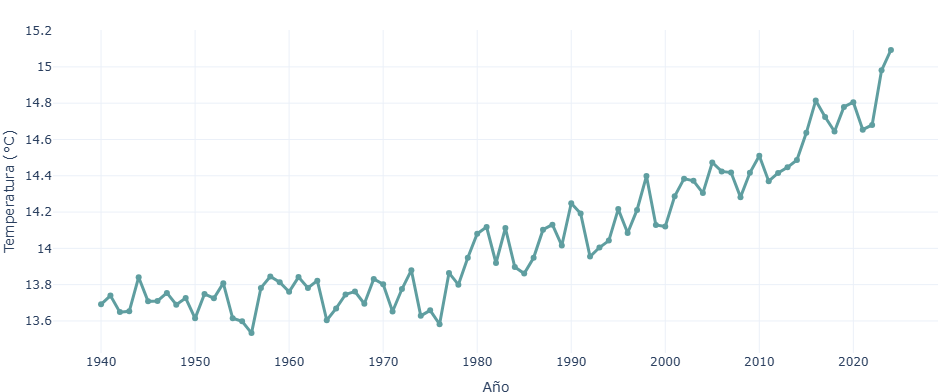

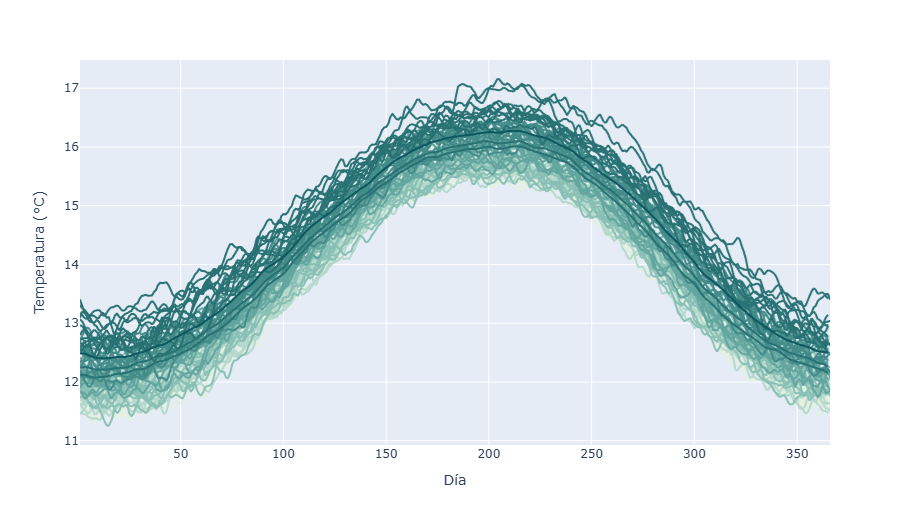

In [7]:
from IPython.display import display, Image

#ARRIBA: Temperatura promedio anual
display(Image(filename='newplot0.png', width=600, height=300))

#ABAJO: Temperatura diaria
display(Image(filename='newplot.png', width=600, height=300))

<div style="background-color: #1e1e1e; color: #3357FF; padding: 10px; border-left: 5px solid #00ffff; font-size: 20px; margin-top: 20px;">
  <b>Creación del Dashboard en Quarto</b>
</div>

<hr style="border: 1px solid #444;">

<div style="background-color: #2a2a2a; color: #dddddd; padding: 20px; border-radius: 10px;">
 Para editar el archivo Quarto cómodamente, se hizo uso de la herramienta <a href='https://code.visualstudio.com/',style="color:#00ffff;">Visual Studio Code</a>. Este editor nos permite trabajar directamente con archivos <code>.qmd</code> (propios de Quarto).

Como inspiración, me basé en los <a href='https://quarto.org/docs/gallery/#dashboards' style="color:#00ffff;">ejemplos de Dashboards</a> dados por Quarto. Dichos ejemplos muestran, además del resultado, el código <code>.qmd</code> y los temas utilizados (que también se pueden descargar). Por tanto, recomiendo primero darles un vistazo para obtener ideas y también para entender la sintaxis de Quarto.

Lo primero que se puede notar es que en un archivo <code>.qmd</code> se debe de empezar escribiendo el código YAML. Este código puede entenderse como el encabezado de nuestro Dashboard, en el cual se incluye el título, el autor, además, para mejorar su apariencia, se pueden colocar logotipos y temas. A continuación, mostraré el YAML que se utilizará en el Dashboard:

  <pre style="background-color: #1e1e1e; color: #00ffff; padding: 15px; border-radius: 10px; overflow-x: auto; margin-top: 20px;">
---
title: "Temperatura del aire superficial en la Tierra"
author: "B. Daniel Muñoz Bravo"
theme: custom.scss
logo: images/gf.png
format:
  dashboard:
    orientation: columns
    sidebar: False
    scroll: False
    layout: columns
execute:
  echo: false
project:
  output-dir: docs
  preview:
    browser: false
---
  </pre>

Aquí utilicé una imagen <code>.png</code> que más adelante se indicará cómo debe guardarse para que el dashboard renderice correctamanete. Aunado a esto, se hizo uso del tema <a href='https://github.com/jjallaire/customer-churn-dashboard/blob/main/custom.scss' style="color:#00ffff;">custom.scss</a>. Por otra parte, prioricé que el acomodo de los elementos del Dashboard sea un columnas.

Luego, para poder escribir lo que ya procesamos en Python, se debe utilizar el siguiente formato

  <pre style="background-color: #1e1e1e; color: #00ffff; padding: 15px; border-radius: 10px; overflow-x: auto; margin-top: 20px;">
```{python} 
#| label: setup
#| include: false
import pandas as pd
import numpy as np
import plotly.express as px

datos = pd.read_json("cambio_clima.json")
datos.rename(columns={"name": "Año", "data": "Temperatura"}, inplace=True)
```

```{python}
#| label: create-graphs
#| output: false

# GRAFICO TEMPERATURA PROMEDIO ANUAL

# PROMEDIOS (TRATA CON DATOS NULOS "None")
def calcular_promedio(lista_temps):
    try:
        temps_numericas = [float(x) for x in lista_temps if x is not None and str(x).replace('.','',1).isdigit()]
        return np.mean(temps_numericas) if temps_numericas else np.nan
    except:
        return np.nan

datos['Promedio'] = datos['Temperatura'].apply(calcular_promedio)
datos = datos.dropna(subset=['Promedio'])
datos_grafico = datos.iloc[:-4] if len(datos) > 4 else datos #QUITAMOS LAS ULTIMAS 4 FILAS
datos_grafico['Año'] = datos_grafico['Año'].astype(int)


fig_anual = px.line(
    datos_grafico,
    x='Año',
    y='Promedio',
    labels={'Promedio': 'Temperatura (°C)'},
    markers=True
)


fig_anual.update_traces(line=dict(width=3, color='cadetblue'))


# GRAFICO REGISTROS DIARIOS

desanidar_datos = datos.explode("Temperatura")
desanidar_datos["Día"] = desanidar_datos.groupby("Año").cumcount() + 1

# Crear gráfico diario
escala_color = px.colors.sequential.Mint
num_datos = len(desanidar_datos["Año"].unique())
indices = np.linspace(0, len(escala_color)-1, num_datos, dtype=int)
colores = [escala_color[i] for i in indices]

fig_diario = px.line(
    desanidar_datos, 
    x='Día', 
    y='Temperatura', 
    color='Año',
    labels={'Temperatura': 'Temperatura (°C)'},
    color_discrete_sequence=colores
)

fig_diario.update_layout(showlegend=False)


```
</pre>

Esto hará que se creen y ejecuten celdas de Python dentro del documento <code>.qmd</code>. Además, los símbolos "#|" sirven para ejecutar órdenes dentro del código de Quarto, como en nuestro caso, que se utilizaron para indicar que no se proyecte el código en el Dashboard resultante ("#| output: false").

Fiinalmente, ya con los datos y gráficos procesados, ya podemos hacer el acomodo de dichos graficos. El acomodo que escogí fue el siguiente:

  <pre style="background-color: #1e1e1e; color: #00ffff; padding: 15px; border-radius: 10px; overflow-x: auto; margin-top: 20px;">
# Dashboard

## Column {width="60%"}

### Row {height="30%"}

#### Column {width="20%"}
```{python}
#| content: valuebox
#| title: "Temperatura promedio anual más alta"
dict(
  icon = "thermometer-high",
  color = "danger",
  value = "15.09°C (2024)"
)
```

#### Column {width="20%"}

```{python}
#| content: valuebox
#| title: "Temperatura promedio anual más baja"
dict(
  icon = "thermometer-low",
  color = "info",
  value = "13.53°C (1956)"
)
```

#### Column {width="20%"}

```{python}
#| content: valuebox
#| title: "Temperatura máxima registrada"
dict(
  icon = "calendar",
  color = "warning",
  value = "17.15 °C 23/07/24"
)
```

### Row{height="70%"}
```{python}
#| title: "Temperatura Promedio Anual"
fig_anual
```

## Column {width="40%"}

```{python}
#| title: "Registro Diario de la Temperatura del Aire"
fig_diario
```

# Base de Datos

```{python}
import pandas as pd
from IPython.display import display, HTML

df = pd.read_excel("cambio_clima.xlsx")

df_preview = df.head(100) #IMPRIMIMOS SOLO 100 FILAS

# TABLA EN HTML

display(HTML(df_preview.to_html(index=False) + mensaje))

```
    
</pre>

Esto nos devolverá dos pestañas, la principal es el dashboard con los respectivos gráficos creados y unos cuantos <b>valuebox</b> con valores relevantes de nuestro conjunto de datos. La segunda pestaña es la base de datos convertida previamente a Excel, con el fin de presentar una tabla más estética. Desde luego, utilizando las funciones de Pandas adecuadas, se puede hacer lo mismo con los datos en formato JSON.

Ya que se tiene el archivo Quarto creado, al momento de correrlo en VS Code, nos devolverá en la carpeta en la guardamos originalmente el archivo, un documento <code>.html</code> y una carpeta con la terminación "_files". Es importante que este documento lo guardemos con el nombre "index". Esto es necesario para poder compartir nuestro dashboard a través de Github Pages.
</div>

<div style="background-color: #1e1e1e; color: #3357FF; padding: 10px; border-left: 5px solid #00ffff; font-size: 20px; margin-top: 20px;">
  <b>Subir el Dashboard a Github Pages</b>
</div>

<hr style="border: 1px solid #444;">

<div style="background-color: #2a2a2a; color: #dddddd; padding: 20px; border-radius: 10px;">
Para este paso me basé completamente en este rápido video tutorial
</div>

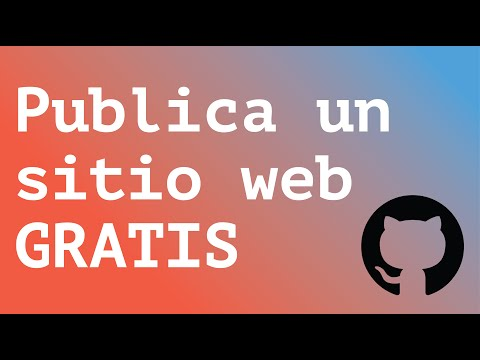

In [10]:
from IPython.display import YouTubeVideo
YouTubeVideo('8IdBAysf-U4', width=560, height=315)

<div style="background-color: #2a2a2a; color: #dddddd; padding: 20px; border-radius: 10px;">
La razón por la que debemos guardar nuestro documento <code>.qmd</code> como 'index' es porque nos devolverá un archivo <code>index.html</code>, el cual, siguiendo los pasos del video, deberemos subir a Github Pages. Es importante que, además de ese archivo, se suba al repositorio la carpeta index_files que se generó automáticamente al crear el Dashboard, y en caso de que se haya descargado un tema, este también debe de ser subido al repositorio. Finalmente, si se utilizó un logotipo, para que renderice correctamente, dentro del repositorio debemos crear una carpeta llamada "images" y dentro de ella se debe subir la imagen utilizada. 
</div>